In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Adam Adnan
- **Email:** adnan100701@gmail.com
- **ID Dicoding:** insight_dt

## Menentukan Pertanyaan Bisnis

- Kapan waktu operasional paling optimal untuk memaksimalkan peminjaman sepeda?
- Segmen pengguna mana (casual vs registered) yang paling berkontribusi terhadap profit dan bagaimana strateginya?
- Bagaimana pengaruh cuaca dan musim terhadap pendapatan dan bagaimana strategi promosi dapat disesuaikan?

## Import Semua Packages/Library yang Digunakan

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

## Data Wrangling

### Gathering Data

In [137]:
day_df = pd.read_csv("/content/drive/MyDrive/Data Science/Project Data Analiyst/Bike-sharing-dataset/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [138]:
hour_df = pd.read_csv("/content/drive/MyDrive/Data Science/Project Data Analiyst/Bike-sharing-dataset/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Tabel day berisi data peminjaman yang sudah dijumlahkan per hari (1 baris = 1 tanggal), sehingga cocok untuk melihat pola umum seperti perubahan jumlah peminjaman berdasarkan bulan/musim, hari kerja atau libur, dan kondisi cuaca.

- Sementara itu, tabel hour berisi data peminjaman per jam (1 tanggal memiliki banyak baris sesuai jam), sehingga cocok untuk melihat jam-jam tertentu yang ramai atau sepi, serta membandingkan pola penggunaan pada hari kerja dan akhir pekan.

### Assessing Data

#### Dataset Day

In [139]:
# Cek Tipe data
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [140]:
day_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [141]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [142]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [143]:
# Cek Validasi logikas cnt = casual + registered
(day_df["cnt"] == day_df["casual"] + day_df["registered"]).value_counts()

,count
True,731


In [144]:
# Cek Range nilai variabel waktu
print("Month range:", day_df["mnth"].min(), "-", day_df["mnth"].max())
print("Weekday range:", day_df["weekday"].min(), "-", day_df["weekday"].max())
print("Season range:", day_df["season"].min(), "-", day_df["season"].max())


Month range: 1 - 12
Weekday range: 0 - 6
Season range: 1 - 4


#### Dataset Hour

In [145]:
# Cek Tipe data
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [146]:
# Cek Missing value
hour_df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [147]:
# Cek Duplikasi
hour_df.duplicated().sum()

np.int64(0)

In [148]:
# Statistik deskriptif
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [149]:
# Cek Validasi Logika cnt
(hour_df["cnt"] == hour_df["casual"] + hour_df["registered"]).value_counts()

,count
True,17379


In [150]:
# Cek Validasi nilai Jam
print("Hour range:", hour_df["hr"].min(), "-", hour_df["hr"].max())

Hour range: 0 - 23


**Insight:**

Hasil pemeriksaan kualitas data menunjukkan bahwa baik dataset day maupun hour tidak memiliki nilai yang hilang (missing values) maupun data duplikat, sehingga data dapat langsung digunakan tanpa proses imputasi atau penghapusan duplikasi.

Namun, ditemukan bahwa beberapa variabel yang bersifat kategorikal seperti season, weathersit, mnth, dan weekday masih direpresentasikan dalam bentuk numerik, yang dapat menyulitkan interpretasi pada tahap visualisasi dan analisis bisnis. Selain itu, kolom dteday masih bertipe object sehingga perlu dikonversi menjadi tipe datetime agar mendukung analisis berbasis waktu.

### Cleaning Data

In [151]:
# Konversi tipe data dteday
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

print(day_df["dteday"].dtypes)
print(hour_df["dteday"].dtypes)

datetime64[ns]
datetime64[ns]


In [152]:
# Mapping season dan weathersit
season_map = {
    1: "Springer",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

weather_map = {
    1: "Clear",
    2: "Mist",
    3: "Light Snow",
    4: "Heavy Rain"
}

for df in [day_df, hour_df]:
    df["season"] = df["season"].map(season_map)
    df["weathersit"] = df["weathersit"].map(weather_map)

In [153]:
# Day
print("Season", day_df['season'].unique())
print("Weathersit", day_df['season'].unique())

Season ['Springer' 'Summer' 'Fall' 'Winter']
Weathersit ['Springer' 'Summer' 'Fall' 'Winter']


In [154]:
# Hour
print("Season", hour_df['season'].unique())
print("Weathersit", hour_df['weathersit'].unique())

Season ['Springer' 'Summer' 'Fall' 'Winter']
Weathersit ['Clear' 'Mist' 'Light Snow' 'Heavy Rain']


In [155]:
# Membuat label hari dan bulan agar visualisasi lebih jelas
for df in [day_df, hour_df]:
    df["weekday"] = df["weekday"].apply(lambda x: calendar.day_name[x])
    df["mnth"] = df["mnth"].apply(lambda x: calendar.month_name[x])

In [156]:
# Day
print("Weekday", day_df["weekday"].unique())
print("Month", day_df["mnth"].unique())

Weekday ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']
Month ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [157]:
# Hour
print("Weekday", hour_df["weekday"].unique())
print("Month", hour_df["mnth"].unique())

Weekday ['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']
Month ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']


In [158]:
# Drop kolom yang tidak relevan
day_df.drop(columns=["instant"], inplace=True)
hour_df.drop(columns=["instant"], inplace=True)

In [159]:
day_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,Springer,0,January,0,Sunday,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2011-01-02,Springer,0,January,0,Monday,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,2011-01-03,Springer,0,January,0,Tuesday,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,2011-01-04,Springer,0,January,0,Wednesday,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,2011-01-05,Springer,0,January,0,Thursday,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [160]:
day_df.to_csv("day.csv", index=False)

In [161]:
hour_df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,2011-01-01,Springer,0,January,0,0,Sunday,0,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2011-01-01,Springer,0,January,1,0,Sunday,0,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,2011-01-01,Springer,0,January,2,0,Sunday,0,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,2011-01-01,Springer,0,January,3,0,Sunday,0,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,2011-01-01,Springer,0,January,4,0,Sunday,0,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [162]:
hour_df.to_csv("hour.csv", index=False)

**Insight:**

Proses cleaning data dilakukan dengan fokus pada peningkatan interpretabilitas data. Kolom dteday dikonversi menjadi tipe datetime untuk mendukung analisis berbasis waktu. Selain itu, beberapa variabel kategorikal seperti season, weathersit, weekday, dan mnth yang sebelumnya direpresentasikan dalam bentuk numerik diubah menjadi label kategori agar lebih mudah dipahami dalam visualisasi dan analisis bisnis.

Tidak dilakukan penghapusan data karena dataset sudah bersih dari missing values dan duplikasi. Dengan demikian, hasil cleaning lebih bersifat transformasi format daripada perbaikan kualitas data.

## Exploratory Data Analysis (EDA)

### Explore - Statistik deskriptif variabel utama

In [163]:
day_df[["cnt", "casual", "registered"]].describe()

,cnt,casual,registered
count,731.000000,731.000000,731.000000
mean,4504.348837,848.176471,3656.172367
std,1937.211452,686.622488,1560.256377
min,22.000000,2.000000,20.000000
25%,3152.000000,315.500000,2497.000000
50%,4548.000000,713.000000,3662.000000
75%,5956.000000,1096.000000,4776.500000
max,8714.000000,3410.000000,6946.000000


In [164]:
hour_df[["cnt", "casual", "registered"]].describe()

,cnt,casual,registered
count,17379.000000,17379.000000,17379.000000
mean,189.463088,35.676218,153.786869
std,181.387599,49.305030,151.357286
min,1.000000,0.000000,0.000000
25%,40.000000,4.000000,34.000000
50%,142.000000,17.000000,115.000000
75%,281.000000,48.000000,220.000000
max,977.000000,367.000000,886.000000


**Insight:**

Variasi peminjaman sangat tinggi (rentang min–maks lebar), sehingga permintaan sepeda cenderung berubah mengikuti waktu dan kondisi tertentu, bukan konstan.

### Explore - Distribusi jumlah peminjaman (cnt)

#### Daily

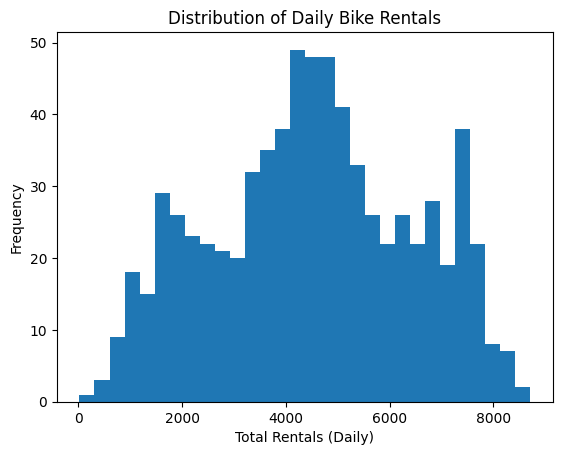

In [165]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(day_df["cnt"], bins=30)
plt.xlabel("Total Rentals (Daily)")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Bike Rentals")
plt.show()


#### Hourly

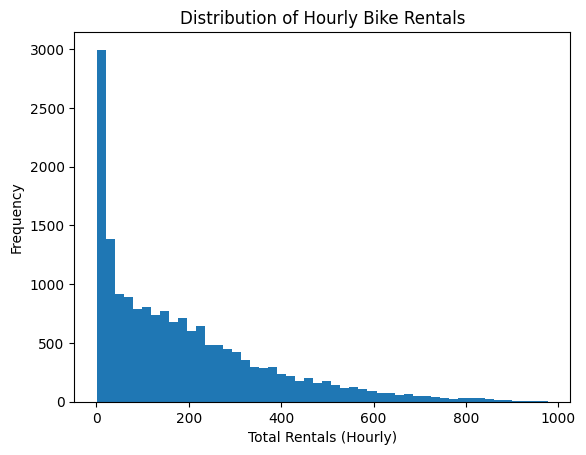

In [166]:
plt.figure()
plt.hist(hour_df["cnt"], bins=50)
plt.xlabel("Total Rentals (Hourly)")
plt.ylabel("Frequency")
plt.title("Distribution of Hourly Bike Rentals")
plt.show()


**Insight:**

Distribusi cnt pada hourly lebih right-skewed, yaitu sebagian besar jam memiliki peminjaman rendah, namun ada beberapa jam dengan lonjakan sangat tinggi (jam puncak). Sementara pada daily, distribusinya lebih merata/terkonsentrasi di nilai tengah, meskipun masih terdapat beberapa hari dengan peminjaman sangat tinggi. Ini menunjukkan adanya pola temporal yang kuat, terutama pada skala jam.

### Explore – Tren peminjaman secara umum terhadap waktu

#### Tren harian (day)

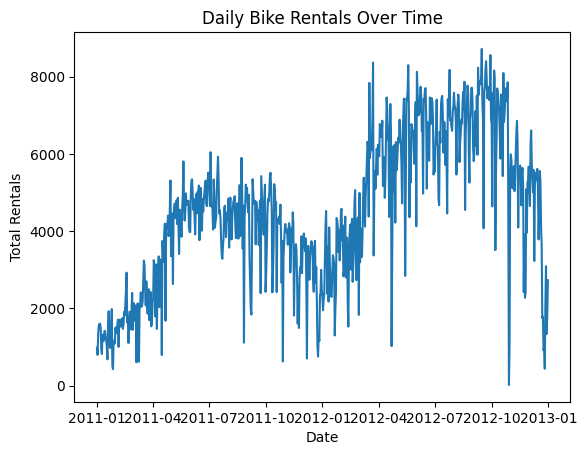

In [167]:
plt.figure()
plt.plot(day_df["dteday"], day_df["cnt"])
plt.xlabel("Date")
plt.ylabel("Total Rentals")
plt.title("Daily Bike Rentals Over Time")
plt.show()

**Insight:**

Tren peminjaman sepeda menunjukkan pola musiman yang jelas, dengan peningkatan jumlah peminjaman pada periode tertentu dan penurunan pada periode lainnya. Secara umum, terlihat adanya tren kenaikan dari tahun 2011 ke 2012, yang mengindikasikan meningkatnya penggunaan sistem bike sharing seiring waktu, meskipun tetap terdapat fluktuasi harian yang cukup signifikan.

### Explore – Perbandingan casual vs registered

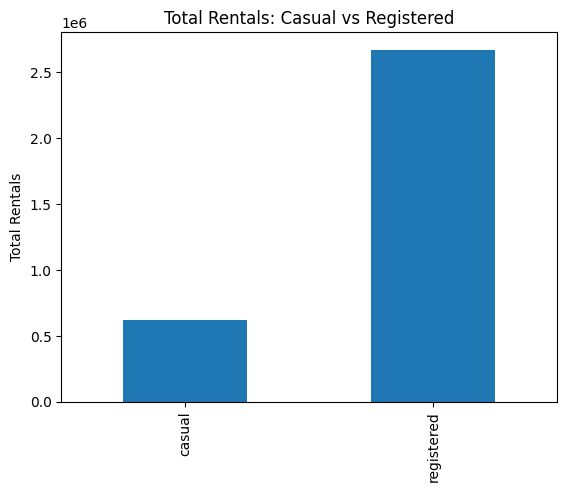

In [168]:
total_users = day_df[["casual", "registered"]].sum()

plt.figure()
total_users.plot(kind="bar")
plt.ylabel("Total Rentals")
plt.title("Total Rentals: Casual vs Registered")
plt.show()


**Insight:**

Total peminjaman sepeda didominasi oleh pengguna terdaftar (registered) dibandingkan pengguna casual dengan selisih yang sangat besar. Hal ini menunjukkan bahwa sistem bike sharing lebih banyak dimanfaatkan oleh pengguna tetap atau rutin, sementara pengguna casual berkontribusi lebih kecil terhadap total permintaan.

### Explore – Korelasi awal antar variabel numerik

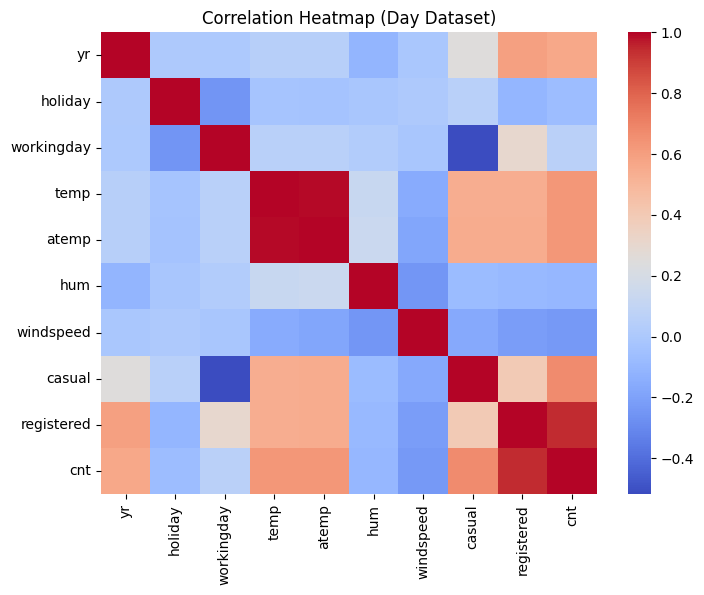

In [169]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(day_df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Day Dataset)")
plt.show()


**Insight:**

cnt berkorelasi kuat dengan registered dan casual (karena cnt = total keduanya). Suhu (temp, atemp) berkorelasi positif dengan cnt, sedangkan hum dan windspeed cenderung lemah/negatif, sehingga cuaca kurang nyaman menurunkan peminjaman.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kapan waktu operasional paling optimal untuk memaksimalkan peminjaman sepeda?

#### Rata-rata peminjaman per jam

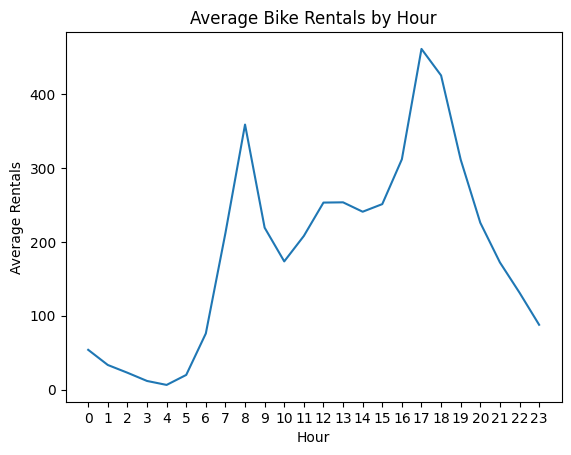

In [170]:
import matplotlib.pyplot as plt

hourly_avg = hour_df.groupby("hr")["cnt"].mean()

plt.figure()
hourly_avg.plot()
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Hour")
plt.xticks(range(0,24))
plt.show()


**Insight:**

Rata-rata peminjaman sepeda menunjukkan dua puncak utama, yaitu pada pagi hari (sekitar 08.00) dan sore hari (sekitar 17.00–18.00), sementara peminjaman terendah terjadi pada dini hari. Pola ini mengindikasikan bahwa penggunaan sepeda sangat dipengaruhi oleh aktivitas rutin harian, seperti perjalanan berangkat dan pulang kerja atau aktivitas harian lainnya.

#### Perbandingan weekday vs weekend

<Figure size 640x480 with 0 Axes>

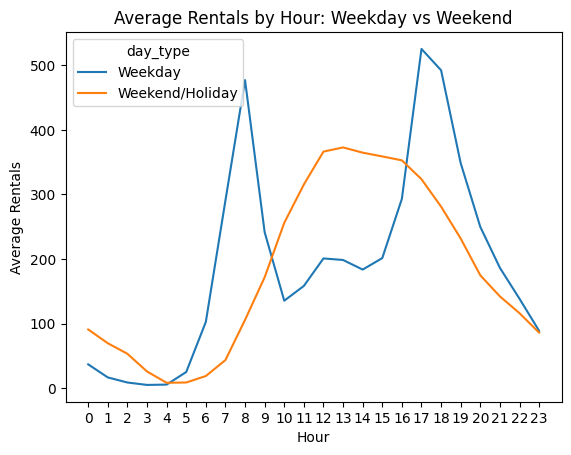

In [171]:
hour_df["day_type"] = hour_df["workingday"].map({1: "Weekday", 0: "Weekend/Holiday"})

hourly_daytype = hour_df.groupby(["hr", "day_type"])["cnt"].mean().unstack()

plt.figure()
hourly_daytype.plot()
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Average Rentals by Hour: Weekday vs Weekend")
plt.xticks(range(0,24))
plt.show()


**Insight:**

Pada hari kerja (weekday), peminjaman sepeda menunjukkan dua puncak tajam pada pagi dan sore hari, yang mencerminkan pola perjalanan rutin. Sebaliknya, pada akhir pekan/libur (weekend), peminjaman meningkat secara bertahap dan mencapai puncak pada siang hingga sore hari, menandakan penggunaan sepeda yang lebih bersifat rekreasi dan tidak terikat jam kerja.

#### Heatmap: kombinasi jam dan hari

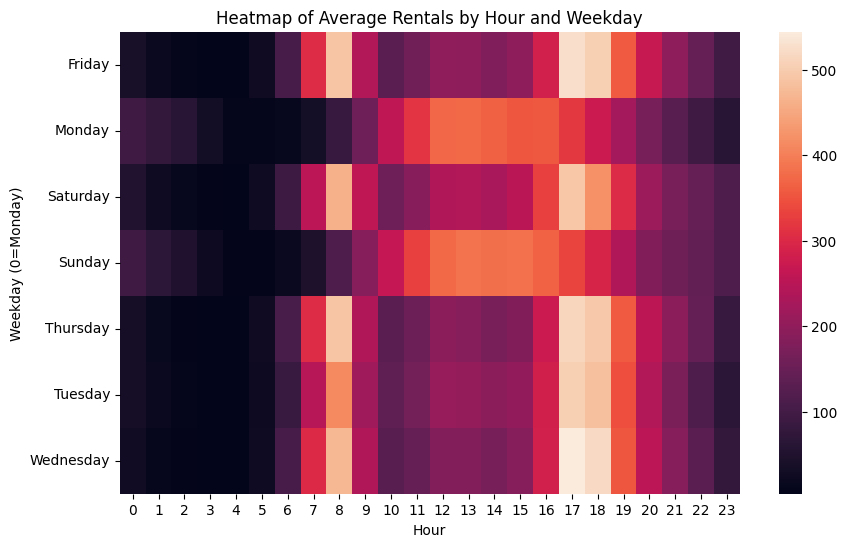

In [172]:
import seaborn as sns

pivot = hour_df.pivot_table(values="cnt", index="weekday", columns="hr", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot)
plt.xlabel("Hour")
plt.ylabel("Weekday (0=Monday)")
plt.title("Heatmap of Average Rentals by Hour and Weekday")
plt.show()


**Insight:**

Heatmap menunjukkan bahwa hari kerja memiliki intensitas peminjaman tertinggi pada pagi (sekitar 07.00–08.00) dan sore (17.00–18.00). Sebaliknya, pada akhir pekan, peminjaman lebih terkonsentrasi pada siang hingga sore hari. Pola ini menegaskan adanya perbedaan perilaku penggunaan sepeda berdasarkan kombinasi hari dan jam.

### Pertanyaan 2: Segmen mana paling menguntungkan?

#### Perbandingan total kontribusi pengguna

In [173]:
total_casual = hour_df["casual"].sum()
total_registered = hour_df["registered"].sum()

print("Total Casual:", total_casual)
print("Total Registered:", total_registered)

Total Casual: 620017
Total Registered: 2672662


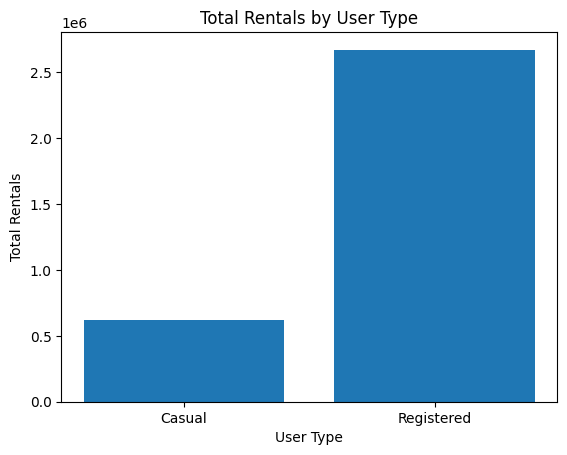

In [174]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(["Casual", "Registered"], [total_casual, total_registered])
plt.xlabel("User Type")
plt.ylabel("Total Rentals")
plt.title("Total Rentals by User Type")
plt.show()

**Insight:**

Total peminjaman sepeda didominasi oleh pengguna terdaftar (registered) dengan jumlah 2.672.662, jauh lebih tinggi dibandingkan pengguna casual sebesar 620.017. Perbedaan yang signifikan ini menunjukkan bahwa aktivitas peminjaman terutama berasal dari pengguna tetap yang menggunakan layanan secara rutin, sehingga segmen registered menjadi kontributor utama terhadap total penggunaan sistem.

#### Pola penggunaan berdasarkan waktu

<Figure size 640x480 with 0 Axes>

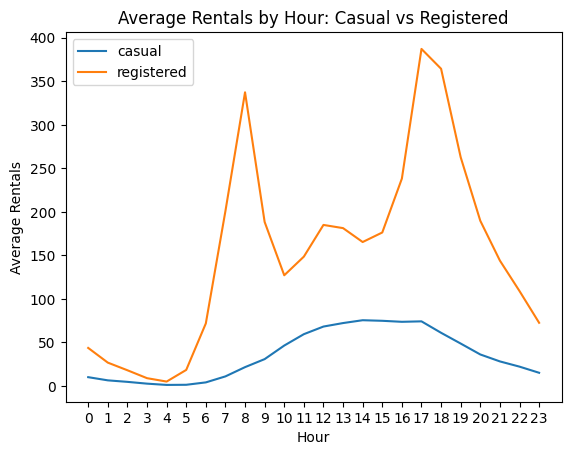

In [175]:
hourly_user = hour_df.groupby("hr")[["casual", "registered"]].mean()

plt.figure()
hourly_user.plot()
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Average Rentals by Hour: Casual vs Registered")
plt.xticks(range(0,24))
plt.show()

**Insight:**

Pengguna registered memiliki dua puncak peminjaman pada pagi dan sore (jam sibuk), sedangkan casual cenderung meningkat pada siang–sore dengan pola lebih stabil. Ini menunjukkan registered lebih rutin, sementara casual lebih fleksibel.

### Pertanyaan 3: Pengaruh cuaca dan musim terhadap pendapatan?

#### Pengaruh cuaca terhadap peminjaman

In [176]:
weather_rentals = hour_df.groupby("weathersit")["cnt"].mean()
print(weather_rentals)

weathersit
Clear         204.869272
Heavy Rain     74.333333
Light Snow    111.579281
Mist          175.165493
Name: cnt, dtype: float64


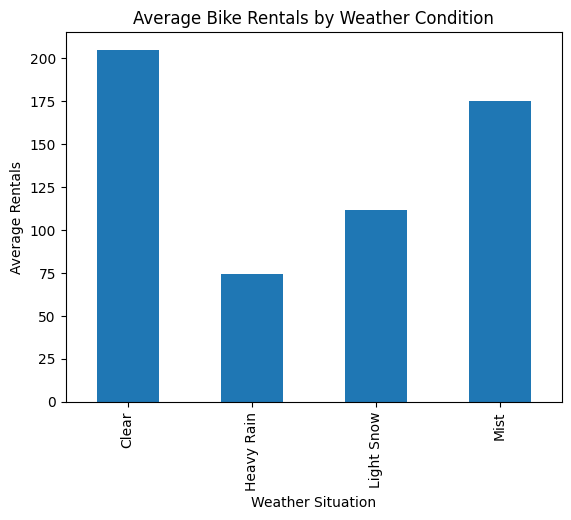

In [177]:
import matplotlib.pyplot as plt

plt.figure()
weather_rentals.plot(kind="bar")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Weather Condition")
plt.show()


**Insight:**

Rata-rata peminjaman sepeda paling tinggi terjadi pada kondisi cuaca cerah (Clear), sedangkan peminjaman menurun tajam saat hujan lebat (Heavy Rain). Pada kondisi Mist dan Light Snow, jumlah peminjaman berada di tingkat menengah. Temuan ini menunjukkan bahwa cuaca sangat memengaruhi tingkat peminjaman, di mana kondisi cuaca yang lebih nyaman mendorong peningkatan penggunaan sepeda, sementara cuaca buruk secara signifikan menekan permintaan.

#### Pengaruh musim

In [178]:
season_rentals = day_df.groupby("season")["cnt"].mean()
print(season_rentals)

season
Fall        5644.303191
Springer    2604.132597
Summer      4992.331522
Winter      4728.162921
Name: cnt, dtype: float64


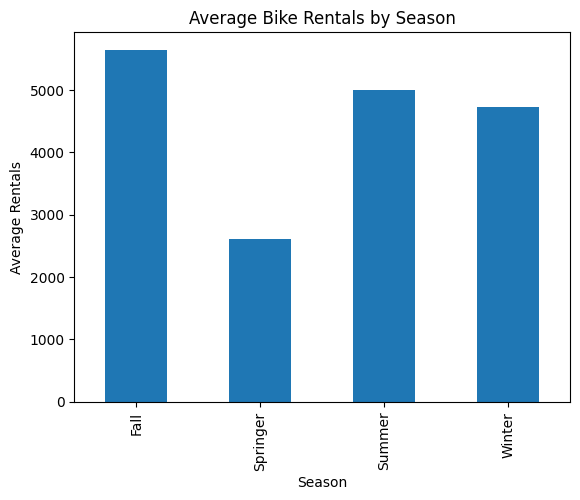

In [179]:
plt.figure()
season_rentals.plot(kind="bar")
plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Season")
plt.show()


**Insight:**

Rata-rata peminjaman sepeda tertinggi terjadi pada musim Fall, diikuti oleh Summer dan Winter, sementara Spring menunjukkan tingkat peminjaman paling rendah. Pola ini mengindikasikan bahwa kondisi musim yang lebih nyaman dan stabil cenderung meningkatkan penggunaan sepeda, sedangkan musim dengan transisi cuaca yang kurang stabil berdampak pada penurunan permintaan.

#### Pengaruh variabel numerik (temp, hum, windspeed)

In [180]:
corr_features = hour_df[["temp", "hum", "windspeed", "cnt"]].corr()
print(corr_features["cnt"])

temp         0.404772
hum         -0.322911
windspeed    0.093234
cnt          1.000000
Name: cnt, dtype: float64


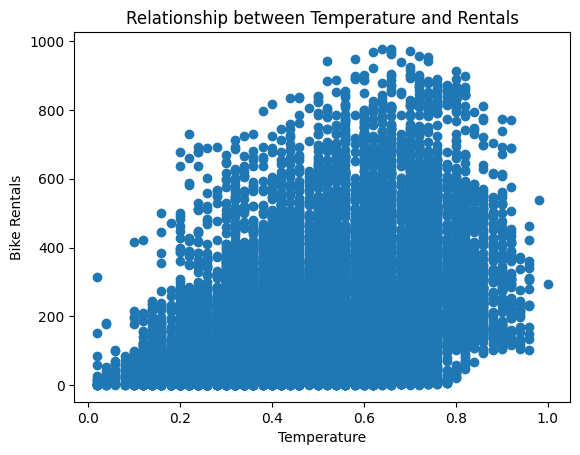

In [181]:
plt.figure()
plt.scatter(hour_df["temp"], hour_df["cnt"])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Relationship between Temperature and Rentals")
plt.show()

**Insight:**

Jumlah peminjaman sepeda memiliki korelasi positif sedang dengan suhu (temp), yang menunjukkan bahwa semakin hangat kondisi udara, peminjaman cenderung meningkat. Sebaliknya, kelembapan (hum) menunjukkan korelasi negatif, sehingga tingkat kelembapan yang tinggi cenderung menurunkan jumlah peminjaman. Sementara itu, kecepatan angin (windspeed) memiliki pengaruh yang sangat lemah terhadap peminjaman. Temuan ini menegaskan bahwa kenyamanan cuaca, khususnya suhu dan kelembapan, berperan lebih penting dibandingkan faktor angin dalam memengaruhi permintaan sepeda.

## Analisis Lanjutan: Clustering

In [182]:
# Membentuk dataset agregasi per jam
hour_cluster = hour_df.groupby("hr")["cnt"].mean().reset_index()
hour_cluster.head()

,hr,cnt
0,0,53.898072
1,1,33.375691
2,2,22.869930
3,3,11.727403
4,4,6.352941


In [183]:
# Clustering berbasis quantile
hour_cluster["demand_level"] = pd.qcut(
    hour_cluster["cnt"],
    q=3,
    labels=["Low Demand", "Medium Demand", "High Demand"]
)

hour_cluster

,hr,cnt,demand_level
0,0,53.898072,Low Demand
1,1,33.375691,Low Demand
2,2,22.869930,Low Demand
3,3,11.727403,Low Demand
4,4,6.352941,Low Demand
5,5,19.889819,Low Demand
6,6,76.044138,Low Demand
7,7,212.064649,Medium Demand
8,8,359.011004,High Demand
9,9,219.309491,Medium Demand


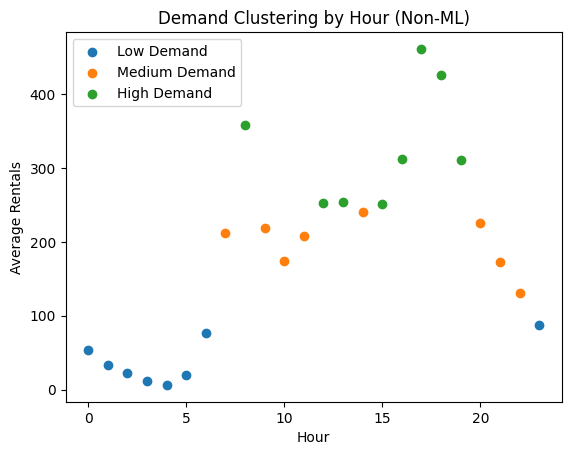

In [184]:
# Visualisasi hasil clustering
plt.figure()
for label in ["Low Demand", "Medium Demand", "High Demand"]:
    subset = hour_cluster[hour_cluster["demand_level"] == label]
    plt.scatter(subset["hr"], subset["cnt"], label=label)

plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Demand Clustering by Hour (Non-ML)")
plt.legend()
plt.show()

In [185]:
hour_cluster.sort_values("cnt")


,hr,cnt,demand_level
4,4,6.352941,Low Demand
3,3,11.727403,Low Demand
5,5,19.889819,Low Demand
2,2,22.869930,Low Demand
1,1,33.375691,Low Demand
0,0,53.898072,Low Demand
6,6,76.044138,Low Demand
23,23,87.831044,Low Demand
22,22,131.335165,Medium Demand
21,21,172.314560,Medium Demand


**Insight:**

Hasil clustering membagi pola permintaan menjadi tiga kelompok yang jelas. Low demand terjadi pada dini hari, ketika aktivitas sangat rendah. Medium demand muncul pada pagi menjelang siang dan malam, saat aktivitas mulai meningkat atau menurun. High demand terkonsentrasi pada jam sibuk pagi dan sore, mencerminkan kebutuhan perjalanan rutin. Pembagian ini menunjukkan bahwa permintaan sepeda sangat bergantung pada waktu, sehingga pengelolaan operasional dan promosi perlu disesuaikan dengan tiap klaster jam.

## Conclusion

1.   Waktu operasional paling optimal untuk memaksimalkan peminjaman sepeda adalah pagi hari (sekitar 07.00–09.00) dan sore hari (sekitar 16.00–18.00) pada hari kerja, karena pada periode tersebut terjadi lonjakan peminjaman tertinggi yang berkaitan dengan aktivitas rutin harian. Sementara itu, pada akhir pekan, waktu optimal bergeser ke siang hingga sore hari (sekitar 11.00–17.00), ketika peminjaman meningkat secara stabil. Temuan ini menunjukkan bahwa strategi operasional sebaiknya disesuaikan dengan perbedaan pola waktu antara hari kerja dan akhir pekan.
2.   Segmen registered merupakan kontributor utama terhadap profit karena memiliki total peminjaman yang jauh lebih tinggi dibandingkan casual serta pola penggunaan yang konsisten pada jam sibuk pagi dan sore. Oleh karena itu, strategi yang paling efektif adalah memfokuskan upaya pada retensi dan optimalisasi pengguna registered melalui program keanggotaan, peningkatan layanan, dan ketersediaan sepeda pada jam puncak, sementara segmen casual dapat dimanfaatkan sebagai peluang tambahan dengan promosi berbasis waktu dan aktivitas rekreatif guna mendorong peningkatan penggunaan dan konversi ke pengguna terdaftar.
3.   Cuaca dan musim memengaruhi pendapatan karena jumlah peminjaman naik saat cuaca cerah dan suhu hangat (terutama Fall dan Summer), tetapi turun saat hujan lebat dan kelembapan tinggi. Strategi promosi sebaiknya dibuat adaptif: maksimalkan kampanye pada cuaca/musim yang mendukung, dan berikan promo khusus saat cuaca buruk atau musim dengan permintaan rendah untuk menjaga pendapatan tetap stabil.



